# Chapter 5 - Overfitting and Underfitting

A model that *memorizes* the training data fails on new data. A model too simple fails everywhere. This chapter makes the two failure modes *visible* and then fixes them.

## The two failure modes
- **Underfitting**: model too small/simple, train loss stays high -> can't learn the training set.
- **Overfitting**: model memorizes noise, train loss ~ 0 but validation loss *rises* after some epoch.

Your diagnostic tool: plot train vs validation loss per epoch.

## Setup - the use IMDB word counting task
We use the small IMDB movie-review dataset as our playground, exactly like chapter 2 but *purposely* with a big network so overfitting shows up. First let's set all seeds + import.

In [1]:
import os
os.environ["TF_CPP_MIN_LOG_LEVEL"] = "2"

import numpy as np
import matplotlib.pyplot as plt

import keras
from keras.datasets import imdb
from keras import layers, models

print("Keras", keras.__version__)

Keras 3.15.1


In [2]:
def vectorize(sequences, dim=4000):
    return np.array([[1 if i in seq else 0 for i in range(dim)] for seq in sequences])

num_words = 10000
(train_data, train_labels), (test_data, test_labels) = imdb.load_data(num_words=num_words)

# keep the notebook fast: a stratified subset for train & val
def subset(data, labels, n=2000, seed=0):
    rng = np.random.RandomState(seed)
    idx = rng.choice(len(data), n, replace=False)
    return [data[i] for i in idx], np.asarray(labels)[idx]

train_data, train_labels = subset(train_data, train_labels, 2000)
test_data, test_labels = subset(test_data, test_labels, 500)

x_train, x_test = vectorize(train_data), vectorize(test_data)
y_train, y_test = np.asarray(train_labels, "int32"), np.asarray(test_labels, "int32")
print(x_train.shape, x_test.shape)

(2000, 4000) (500, 4000)


In [3]:
def build_large_model():
    model = models.Sequential([
        layers.Input(shape=(4000,)),
        layers.Dense(512, activation="relu"),
        layers.Dense(512, activation="relu"),
        layers.Dense(1, activation="sigmoid"),
    ])
    model.compile(optimizer="rmsprop", loss="binary_crossentropy", metrics=["accuracy"])
    return model

In [4]:
# A LOT of training + few samples -> guaranteed overfitting
model = build_large_model()
history = model.fit(x_train, y_train,
                    validation_data=(x_test, y_test),
                    epochs=20, batch_size=512, verbose=1)

Epoch 1/20


1/4 ━━━━━━━━━━━━━━━━━━━━ 1s 546ms/step - accuracy: 0.5410 - loss: 0.6928

4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 20ms/step - accuracy: 0.5095 - loss: 0.7604 

4/4 ━━━━━━━━━━━━━━━━━━━━ 1s 74ms/step - accuracy: 0.5095 - loss: 0.7604 - val_accuracy: 0.4820 - val_loss: 0.6821


Epoch 2/20


...

4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 36ms/step - accuracy: 1.0000 - loss: 0.0162 - val_accuracy: 0.8540 - val_loss: 0.4150


Epoch 20/20


1/4 ━━━━━━━━━━━━━━━━━━━━ 0s 39ms/step - accuracy: 1.0000 - loss: 0.0133

4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 19ms/step - accuracy: 1.0000 - loss: 0.0128

4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 38ms/step - accuracy: 1.0000 - loss: 0.0128 - val_accuracy: 0.8560 - val_loss: 0.4291


## Look at what overfitting looks like
After a few epochs validation loss bottoms out and then *starts climbing*, while training loss keeps dropping to near zero. That's the textbook overfitting curve.

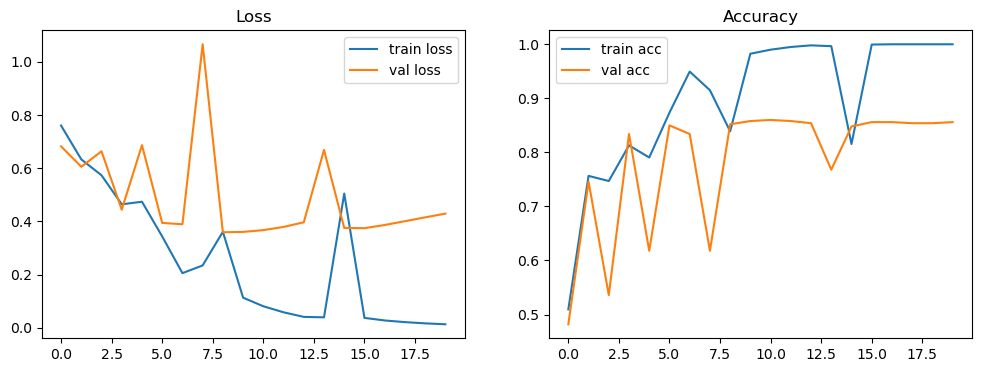

In [5]:
def plot_history(history):
    fig, ax = plt.subplots(1, 2, figsize=(12, 4))
    ax[0].plot(history.history["loss"], label="train loss")
    ax[0].plot(history.history["val_loss"], label="val loss")
    ax[0].set_title("Loss"); ax[0].legend()
    ax[1].plot(history.history["accuracy"], label="train acc")
    ax[1].plot(history.history["val_accuracy"], label="val acc")
    ax[1].set_title("Accuracy"); ax[1].legend()
    plt.show()

plot_history(history)

## Underfitting: make *a* network so small it can't learn
The contrast: cap L2 penalty, tiny hidden layer. Both train & val stay "bad" — that's underfitting.

Epoch 1/10


1/4 ━━━━━━━━━━━━━━━━━━━━ 1s 451ms/step - accuracy: 0.5020 - loss: 0.7015

4/4 ━━━━━━━━━━━━━━━━━━━━ 1s 55ms/step - accuracy: 0.5095 - loss: 0.6953 - val_accuracy: 0.5380 - val_loss: 0.6902


Epoch 2/10


1/4 ━━━━━━━━━━━━━━━━━━━━ 0s 24ms/step - accuracy: 0.6016 - loss: 0.6861

...

1/4 ━━━━━━━━━━━━━━━━━━━━ 0s 23ms/step - accuracy: 0.8418 - loss: 0.5181

4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 18ms/step - accuracy: 0.8395 - loss: 0.5222 - val_accuracy: 0.6960 - val_loss: 0.5719


Epoch 10/10


1/4 ━━━━━━━━━━━━━━━━━━━━ 0s 26ms/step - accuracy: 0.8438 - loss: 0.4927

4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 18ms/step - accuracy: 0.8580 - loss: 0.5072 - val_accuracy: 0.6800 - val_loss: 0.5675


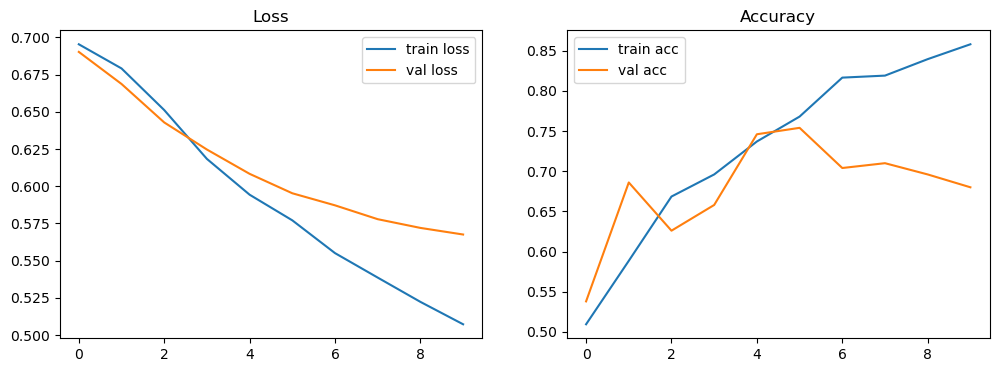

In [6]:
def build_tiny_model():
    model = models.Sequential([
        layers.Input(shape=(4000,)),
        layers.Dense(4, activation="relu"),
        layers.Dense(4, activation="relu"),
        layers.Dense(1, activation="sigmoid"),
    ])
    model.compile(optimizer="rmsprop", loss="binary_crossentropy", metrics=["accuracy"])
    return model

model_tiny = build_tiny_model()
hist_tiny = model_tiny.fit(x_train, y_train, validation_data=(x_test, y_test), epochs=10, batch_size=512, verbose=1)
plot_history(hist_tiny)

## 3 fixes: weight decay (L2), dropout, early stopping
These are the main tools we use against overfitting until the batch-norm in the convnets chapter.

In [7]:
def build_regularized():
    model = models.Sequential([
        layers.Input(shape=(4000,)),
        layers.Dense(512, activation="relu", kernel_regularizer="l2"),
        layers.Dense(512, activation="relu", kernel_regularizer="l2"),
        layers.Dense(1, activation="sigmoid"),
    ])
    model.compile(optimizer="rmsprop", loss="binary_crossentropy", metrics=["accuracy"])
    return model

Epoch 1/20


 1/16 ━━━━━━━━━━━━━━━━━━━━ 8s 536ms/step - accuracy: 0.6094 - loss: 14.8803

 5/16 ━━━━━━━━━━━━━━━━━━━━ 0s 15ms/step - accuracy: 0.5203 - loss: 12.7490 

 9/16 ━━━━━━━━━━━━━━━━━━━━ 0s 15ms/step - accuracy: 0.5946 - loss: 11.1760

13/16 ━━━━━━━━━━━━━━━━━━━━ 0s 15ms/step - accuracy: 0.6376 - loss: 9.9502 

...

 1/16 ━━━━━━━━━━━━━━━━━━━━ 0s 35ms/step - accuracy: 0.9219 - loss: 0.4245

 5/16 ━━━━━━━━━━━━━━━━━━━━ 0s 14ms/step - accuracy: 0.9703 - loss: 0.3354

 9/16 ━━━━━━━━━━━━━━━━━━━━ 0s 14ms/step - accuracy: 0.9740 - loss: 0.3256

13/16 ━━━━━━━━━━━━━━━━━━━━ 0s 14ms/step - accuracy: 0.9681 - loss: 0.3292

16/16 ━━━━━━━━━━━━━━━━━━━━ 0s 18ms/step - accuracy: 0.9435 - loss: 0.3716 - val_accuracy: 0.8180 - val_loss: 0.6662


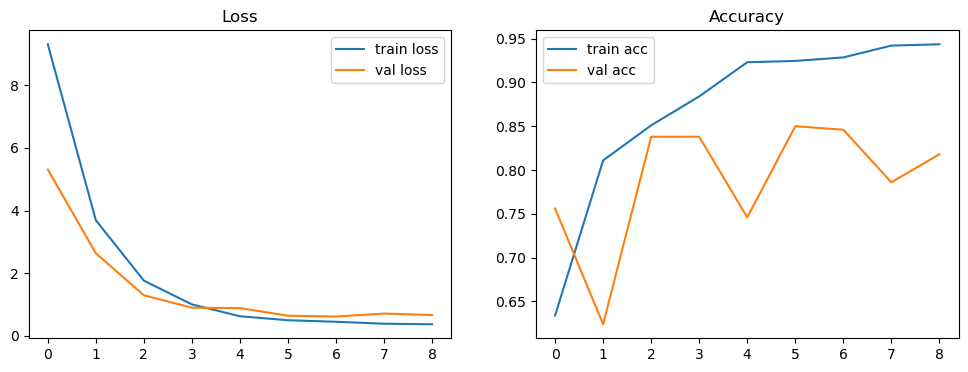

In [8]:
from keras.callbacks import EarlyStopping

model_reg = build_regularized()
hist_reg = model_reg.fit(
    x_train, y_train, validation_data=(x_test, y_test),
    epochs=20, batch_size=128, verbose=1,
    callbacks=[EarlyStopping(monitor="val_loss", patience=2)],
)
plot_history(hist_reg)

## Add dropout to the large net — compare against the unregularized one

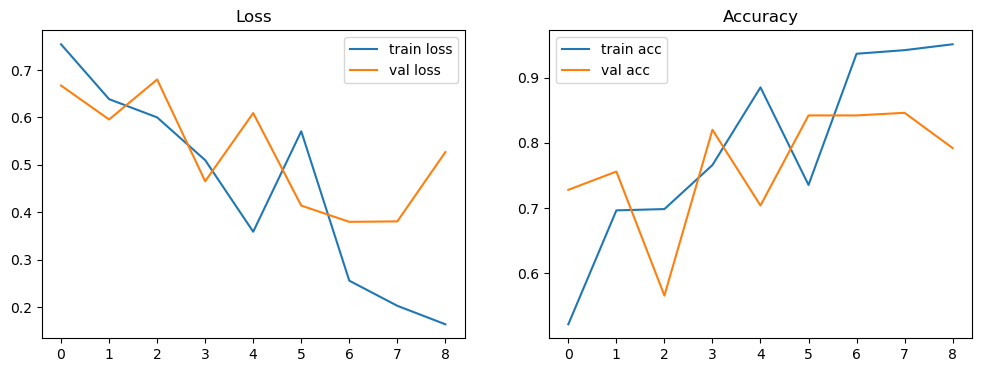

In [9]:
def build_dropout():
    model = models.Sequential([
        layers.Input(shape=(4000,)),
        layers.Dense(512, activation="relu"),
        layers.Dropout(0.5),
        layers.Dense(512, activation="relu"),
        layers.Dropout(0.5),
        layers.Dense(1, activation="sigmoid"),
    ])
    model.compile(optimizer="rmsprop", loss="binary_crossentropy", metrics=["accuracy"])
    return model

model_drop = build_dropout()
hist_drop = model_drop.fit(x_train, y_train, validation_data=(x_test, y_test),
                           epochs=20, batch_size=512, verbose=0,
                           callbacks=[EarlyStopping(monitor="val_loss", patience=2)])
plot_history(hist_drop)

## Recap & take-home
- Overfit signature: train+loss small, val+loss rising. Underfit: both poor.
- Fixes that work: reduce capacity, L2 regularization (weight decay), dropout, early stopping.
- The cure is rarely a single knob; batch-norm also matters (coming up in convnets).